# BASELINE: MLP 64-32 huấn luyện TRỰC TIẾP (KHÔNG chưng cất tri thức)

Bản đối chứng cho thí nghiệm Knowledge Distillation.

**Giữ nguyên so với bản KD:** kiến trúc MLP [64, 32] + ReLU, không BatchNorm,
BATCH_SIZE = 128, LEARNING_RATE = 0.005, ReduceLROnPlateau (patience 5, factor 0.5),
gradient clipping 1.0, class weights capped tại 3.0, toàn bộ phần đánh giá cuối.

**Khác biệt duy nhất:** loss chỉ là weighted Cross-Entropy (bỏ teacher CNN + XGBoost,
bỏ KD loss, bỏ ALPHA / TEMPERATURE). Ngoài ra `EPOCHS = 50` và `min_lr = 1e-5`.

In [1]:
import os
import json
import pandas as pd

OUTPUT_DIR = "/kaggle/working/"
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
metadata_path = f"{OUTPUT_DIR}/metadata.json"

def create_metadata_from_parquet(train_path):
    df = pd.read_parquet(train_path)
    all_columns = df.columns.tolist()
    target_col = 'label'
    if target_col not in all_columns:
        raise ValueError(f"Target column '{target_col}' not found.")
    feature_cols = [col for col in all_columns if col != target_col]
    num_features = len(feature_cols)
    unique_labels = sorted(df[target_col].astype(str).unique())
    num_classes = len(unique_labels)
    label_to_id = {label: idx for idx, label in enumerate(unique_labels)}
    id_to_label = {str(idx): label for idx, label in enumerate(unique_labels)}
    metadata = {
        "feature_cols": feature_cols,
        "target_col": target_col,
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
        "num_classes": num_classes,
        "num_features": num_features
    }
    return metadata

if not os.path.exists(metadata_path):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    metadata = create_metadata_from_parquet(TRAIN_PATH)
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata saved to {metadata_path}")
else:
    print("Metadata already exists.")

Metadata saved to /kaggle/working//metadata.json


In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 1: Imports & Config  (BASELINE - không chưng cất)
# ──────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time

# Hyperparameters (giữ nguyên như bản KD, trừ EPOCHS)
BATCH_SIZE    = 128
LEARNING_RATE = 0.005
EPOCHS        = 100
# TEMPERATURE / ALPHA: KHÔNG dùng ở baseline (không có teacher)

# Paths
OUTPUT_DIR    = "/kaggle/working/"
METADATA_PATH = f"{OUTPUT_DIR}/metadata.json"
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
VAL_PATH   = "/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet"
TEST_PATH  = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
# Không load XGB_MODEL_PATH / DNN_MODEL_PATH -> baseline không cần teacher

# Đặt seed để so sánh công bằng với bản KD
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 2: Load Data + Class Weights (max = 3.0)
# ──────────────────────────────────────────────────────────────────────────────
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
target_col   = metadata['target_col']
num_classes  = metadata['num_classes']
num_features = metadata['num_features']

df_train = pd.read_parquet(TRAIN_PATH)
df_val   = pd.read_parquet(VAL_PATH)
df_test  = pd.read_parquet(TEST_PATH)

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train[target_col].values.astype(np.int32)
X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val[target_col].values.astype(np.int32)
X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test[target_col].values.astype(np.int32)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Number of classes: {num_classes}")

# Tính class weights dựa trên y_train (đã undersampled)
from sklearn.utils.class_weight import compute_class_weight

unique_classes = np.unique(y_train)
class_weights_raw = compute_class_weight('balanced', classes=unique_classes, y=y_train)
# Giới hạn weight tối đa = 3.0
MAX_WEIGHT = 3.0
class_weights = np.minimum(class_weights_raw, MAX_WEIGHT)

print("Class counts:", np.bincount(y_train))
print("Class weights (capped at 3.0):", class_weights)

# Chuyển thành tensor để dùng trong loss
class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)

Train: (4468344, 37), Val: (1117087, 37), Test: (1396358, 37)
Number of classes: 8
Class counts: [ 670231 1916729  619802    8013  278953  383443   15173  576000]
Class weights (capped at 3.0): [0.83335895 0.29140426 0.9011636  3.         2.00228354 1.45665197
 3.         0.96969271]


I0000 00:00:1786264750.823425      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786264750.826299      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 3: Build MLP Model (64-32, ReLU, no BatchNorm, outputs logits)
# ──────────────────────────────────────────────────────────────────────────────
def build_mlp(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='linear')   # logits
    ])
    return model

student = build_mlp(num_features, num_classes)   # giữ tên biến 'student' để tái dùng code đánh giá
student.summary()
print(f"Model parameters: {student.count_params()}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,776 (18.66 KB)

 Trainable params: 4,776 (18.66 KB)

 Non-trainable params: 0 (0.00 B)

Model parameters: 4776


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 4: Create tf.data.Datasets (chỉ X, y - KHÔNG có teacher probs)
# ──────────────────────────────────────────────────────────────────────────────
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Train batches: {len(train_dataset)}, Val batches: {len(val_dataset)}")

Train batches: 34909, Val batches: 8728


In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 5: Checkpoint helpers
# ──────────────────────────────────────────────────────────────────────────────
import pickle
import glob
import json
import tensorflow as tf

CHECKPOINT_DIR = f"{OUTPUT_DIR}/training_checkpoints_baseline"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# File lưu metadata
METADATA_FILE = f"{CHECKPOINT_DIR}/metadata.pkl"

def save_metadata(epoch, best_val_loss, wait_lr, current_lr,
                  train_losses, val_losses, train_accuracies, val_accuracies, best_weights):
    metadata = {
        'epoch': epoch,
        'best_val_loss': best_val_loss,
        'wait_lr': wait_lr,
        'current_lr': current_lr,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_weights': best_weights
    }
    with open(METADATA_FILE, 'wb') as f:
        pickle.dump(metadata, f)

def load_metadata():
    if not os.path.exists(METADATA_FILE):
        return None, 0
    with open(METADATA_FILE, 'rb') as f:
        metadata = pickle.load(f)
    return metadata, metadata['epoch']

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 6: Training Loop - BASELINE (weighted Cross-Entropy, không KD)
# ──────────────────────────────────────────────────────────────────────────────
from tqdm.auto import tqdm
import tensorflow as tf

GRAD_CLIP_NORM = 1.0

# Khởi tạo optimizer (Adam)
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)

# Tạo checkpoint object (lưu model + optimizer)
checkpoint = tf.train.Checkpoint(model=student, optimizer=optimizer)
checkpoint_manager = tf.train.CheckpointManager(
    checkpoint,
    directory=CHECKPOINT_DIR,
    max_to_keep=2
)

# Load metadata và checkpoint nếu có
metadata_ckpt, start_epoch = load_metadata()
if metadata_ckpt is not None:
    print(f"Resuming from epoch {start_epoch}")
    best_val_loss    = metadata_ckpt['best_val_loss']
    wait_lr          = metadata_ckpt['wait_lr']
    current_lr       = metadata_ckpt['current_lr']
    train_losses     = metadata_ckpt['train_losses']
    val_losses       = metadata_ckpt['val_losses']
    train_accuracies = metadata_ckpt['train_accuracies']
    val_accuracies   = metadata_ckpt['val_accuracies']
    best_weights     = metadata_ckpt['best_weights']
    latest_checkpoint = tf.train.latest_checkpoint(CHECKPOINT_DIR)
    if latest_checkpoint is not None:
        checkpoint.restore(latest_checkpoint).expect_partial()
        print(f"  ✅ Restored model and optimizer from {latest_checkpoint}")
    else:
        print("  ⚠️  No checkpoint file found, but metadata exists. Starting fresh.")
    epoch_start = start_epoch + 1
else:
    print("Starting fresh training")
    best_val_loss    = float('inf')
    best_weights     = None
    wait_lr          = 0
    current_lr       = LEARNING_RATE
    train_losses     = []
    val_losses       = []
    train_accuracies = []
    val_accuracies   = []
    epoch_start      = 1

# Các tham số ReduceLROnPlateau
patience_lr = 5
lr_factor   = 0.5
min_lr      = 1e-4

# ── Hàm train_step: CHỈ weighted CE loss ────────────────────────────────────
@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        student_logits = student(x_batch, training=True)
        loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=y_batch, logits=student_logits
        )
        sample_weights = tf.gather(class_weights_tensor, y_batch)
        loss = tf.reduce_mean(loss_per_sample * sample_weights)

    grads = tape.gradient(loss, student.trainable_variables)
    # Gradient clipping
    grads, _ = tf.clip_by_global_norm(grads, GRAD_CLIP_NORM)
    optimizer.apply_gradients(zip(grads, student.trainable_variables))
    return loss

@tf.function
def eval_step(x_batch, y_batch):
    student_logits = student(x_batch, training=False)
    loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=y_batch, logits=student_logits
    )
    sample_weights = tf.gather(class_weights_tensor, y_batch)
    loss = tf.reduce_mean(loss_per_sample * sample_weights)
    return loss, student_logits

# Đo tổng thời gian huấn luyện (phục vụ so sánh chi phí với bản KD)
total_train_time = 0.0

# Vòng lặp training
for epoch in range(epoch_start, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS} (LR = {current_lr:.6f})")
    epoch_start_time = time.perf_counter()
    epoch_loss  = 0.0
    num_batches = 0

    # Training
    pbar = tqdm(train_dataset, desc="Training", unit="batch")
    for x_batch, y_batch in pbar:
        loss = train_step(x_batch, y_batch)
        epoch_loss += loss.numpy()
        num_batches += 1
        pbar.set_postfix({"loss": f"{loss.numpy():.4f}"})

    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    total_train_time += time.perf_counter() - epoch_start_time

    # Train accuracy
    train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    for x_batch, y_batch in train_dataset:
        student_logits = student(x_batch, training=False)
        train_acc_metric.update_state(y_batch, student_logits)
    train_acc = train_acc_metric.result().numpy()
    train_accuracies.append(train_acc)

    # Validation
    val_loss_epoch  = 0.0
    val_num_batches = 0
    val_acc_metric  = tf.keras.metrics.SparseCategoricalAccuracy()

    for x_batch, y_batch in val_dataset:
        loss_val, student_logits = eval_step(x_batch, y_batch)
        val_loss_epoch += loss_val.numpy()
        val_num_batches += 1
        val_acc_metric.update_state(y_batch, student_logits)

    avg_val_loss = val_loss_epoch / val_num_batches
    val_losses.append(avg_val_loss)
    val_acc = val_acc_metric.result().numpy()
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Lưu checkpoint (model + optimizer)
    checkpoint_manager.save()
    print(f"  💾 Checkpoint saved at epoch {epoch}")

    # Lưu metadata
    save_metadata(epoch, best_val_loss, wait_lr, current_lr,
                  train_losses, val_losses, train_accuracies, val_accuracies, best_weights)

    # ModelCheckpoint (best by val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_weights = student.get_weights()
        student.save("/kaggle/working/mlp_baseline_best.keras")
        print(f"  ✅ New best model saved with val_loss = {avg_val_loss:.6f}")
        wait_lr = 0
    else:
        wait_lr += 1

    # ReduceLROnPlateau
    if wait_lr >= patience_lr and current_lr > min_lr:
        current_lr = max(current_lr * lr_factor, min_lr)
        if hasattr(optimizer.learning_rate, 'assign'):
            optimizer.learning_rate.assign(current_lr)
        else:
            optimizer.learning_rate = current_lr
        wait_lr = 0
        print(f"  🔻 Learning rate reduced to {current_lr:.6f}")

# Restore best weights
if best_weights is not None:
    student.set_weights(best_weights)
    print(f"\nRestored best model with val_loss = {best_val_loss:.6f}")

print(f"Tổng thời gian huấn luyện: {total_train_time:.2f} s "
      f"({total_train_time/max(1,(EPOCHS - epoch_start + 1)):.2f} s/epoch)")

# Lưu history để so sánh với bản KD
with open(f"{OUTPUT_DIR}/history_baseline.json", "w") as f:
    json.dump({
        "train_losses": [float(v) for v in train_losses],
        "val_losses": [float(v) for v in val_losses],
        "train_accuracies": [float(v) for v in train_accuracies],
        "val_accuracies": [float(v) for v in val_accuracies],
        "best_val_loss": float(best_val_loss),
        "total_train_time_sec": float(total_train_time)
    }, f, indent=2)

# Xóa checkpoint
import shutil
shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)
print("Checkpoints cleaned up.")
print("Training completed!")

Starting fresh training

Epoch 1/100 (LR = 0.005000)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 1 | Train Loss: 0.4014 | Val Loss: 0.3714 | Train Acc: 0.7745 | Val Acc: 0.7743
  💾 Checkpoint saved at epoch 1
  ✅ New best model saved with val_loss = 0.371443

Epoch 2/100 (LR = 0.005000)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 2 | Train Loss: 0.3626 | Val Loss: 0.3516 | Train Acc: 0.7805 | Val Acc: 0.7804
  💾 Checkpoint saved at epoch 2
  ✅ New best model saved with val_loss = 0.351585

Epoch 3/100 (LR = 0.005000)


...

Epoch 98 | Train Loss: 0.3038 | Val Loss: 0.3086 | Train Acc: 0.8185 | Val Acc: 0.8178
  💾 Checkpoint saved at epoch 98

Epoch 99/100 (LR = 0.000100)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 99 | Train Loss: 0.3038 | Val Loss: 0.3087 | Train Acc: 0.8185 | Val Acc: 0.8178
  💾 Checkpoint saved at epoch 99

Epoch 100/100 (LR = 0.000100)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 100 | Train Loss: 0.3038 | Val Loss: 0.3090 | Train Acc: 0.8185 | Val Acc: 0.8177
  💾 Checkpoint saved at epoch 100

Restored best model with val_loss = 0.308565
Tổng thời gian huấn luyện: 10788.77 s (107.89 s/epoch)
Checkpoints cleaned up.
Training completed!


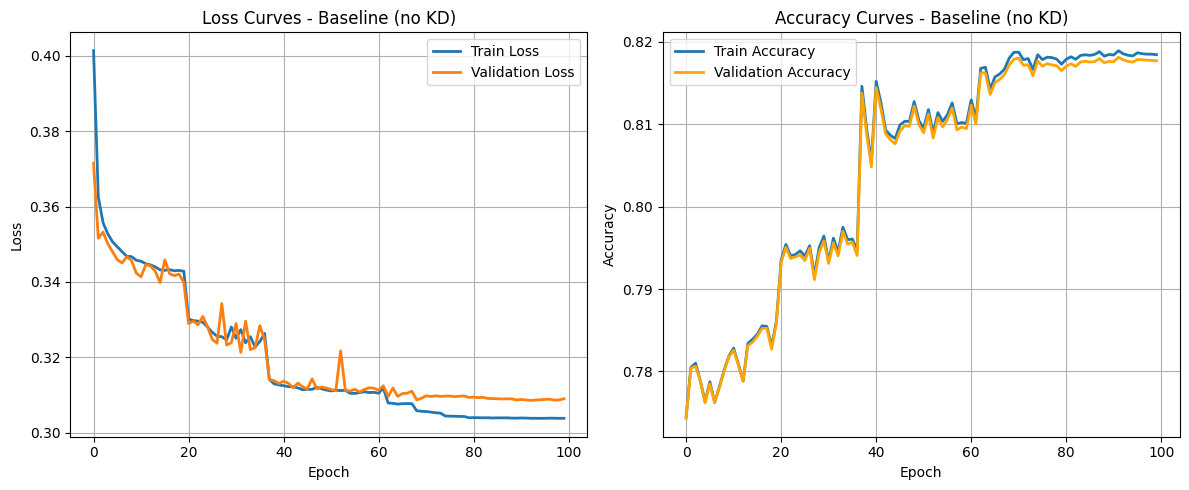

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 7: Plot Training Curves
# ──────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12,5))

# Subplot 1: Loss curves
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves - Baseline (no KD)')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy curves
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', linewidth=2, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves - Baseline (no KD)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves_baseline.png", dpi=150)
plt.show()

  109/10910 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step

I0000 00:00:1786307013.480609      78 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10910/10910 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
===== Classification Report =====
              precision    recall  f1-score   support

           0       0.85      0.82      0.84    209448
           1       0.96      0.74      0.84    598978
           2       0.53      0.90      0.67    193688
           3       0.74      0.28      0.40      2504
           4       0.85      0.87      0.86     87173
           5       0.71      0.78      0.74    119826
           6       0.57      0.13      0.22      4741
           7       1.00      1.00      1.00    180000

    accuracy                           0.82   1396358
   macro avg       0.78      0.69      0.70   1396358
weighted avg       0.86      0.82      0.83   1396358



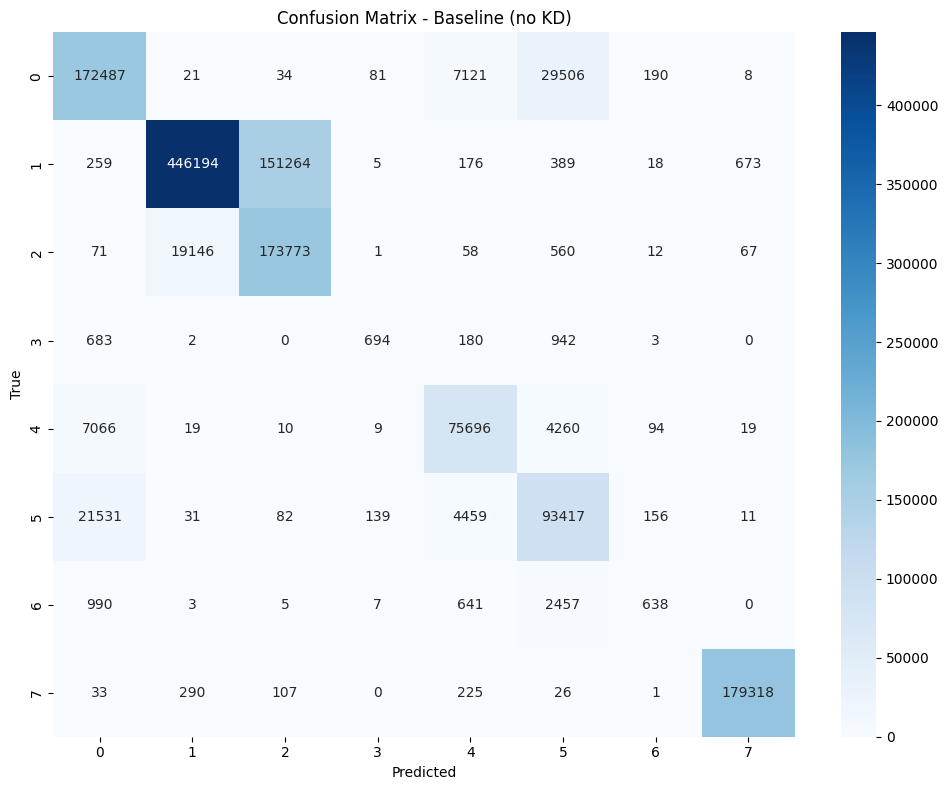

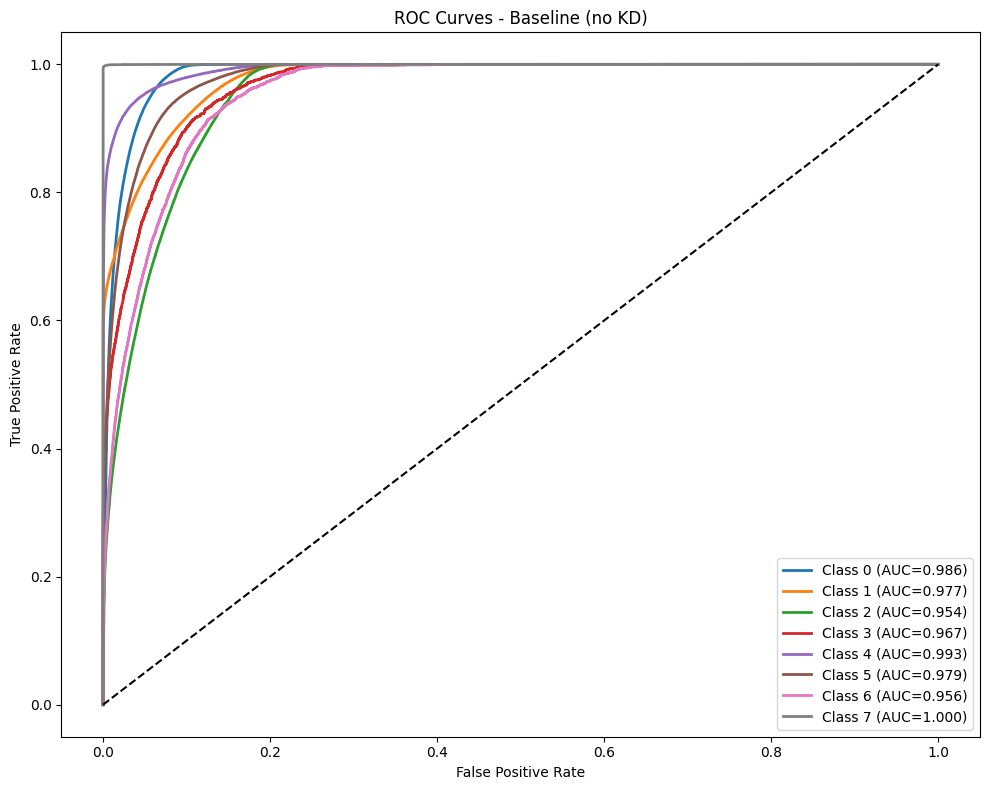

In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 8: Evaluation on Test Set
# ──────────────────────────────────────────────────────────────────────────────
test_logits = student.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_preds = np.argmax(test_logits, axis=1)
test_probs = tf.nn.softmax(test_logits).numpy()

print("===== Classification Report =====")
print(classification_report(y_test, test_preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - Baseline (no KD)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_baseline.png", dpi=150)
plt.show()

# ROC Curves
y_bin = label_binarize(y_test, classes=range(num_classes))
plt.figure(figsize=(10,8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Baseline (no KD)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves_baseline.png", dpi=150)
plt.show()

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 9: Heaviness Metrics
# ──────────────────────────────────────────────────────────────────────────────
# Model size
student.save("temp_student.keras")
size_mb = os.path.getsize("temp_student.keras") / (1024*1024)
os.remove("temp_student.keras")
print(f"Model size: {size_mb:.4f} MB")
print(f"Total parameters: {student.count_params()}")

# Approximate FLOPs
def approx_flops(model):
    total = 0
    for layer in model.layers:
        if len(layer.weights) > 0:  # Dense layers có weights
            kernel = layer.weights[0]  # shape (input_dim, output_dim)
            input_dim = kernel.shape[0]
            output_dim = kernel.shape[1]
            total += input_dim * output_dim + output_dim  # phép nhân + bias
    return total

print(f"FLOPs per sample (approx): {approx_flops(student)}")

# Inference time
N = 2000
start = time.perf_counter()
student.predict(X_test[:N], batch_size=BATCH_SIZE, verbose=0)
inf_time = (time.perf_counter() - start) / N * 1000  # ms per sample
print(f"Inference time per sample: {inf_time:.4f} ms")

Model size: 0.0358 MB
Total parameters: 4776
FLOPs per sample (approx): 4776
Inference time per sample: 0.1744 ms


10910/10910 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step

CLASSIFICATION REPORT (digits=4)
              precision    recall  f1-score   support

           0     0.8492    0.8235    0.8362    209448
           1     0.9581    0.7449    0.8382    598978
           2     0.5342    0.8972    0.6697    193688
           3     0.7415    0.2772    0.4035      2504
           4     0.8548    0.8683    0.8615     87173
           5     0.7101    0.7796    0.7432    119826
           6     0.5737    0.1346    0.2180      4741
           7     0.9957    0.9962    0.9959    180000

    accuracy                         0.8180   1396358
   macro avg     0.7772    0.6902    0.6958   1396358
weighted avg     0.8584    0.8180    0.8253   1396358


----------------------------------------
Macro AUC   : 0.9767
Weighted AUC: 0.9794
Micro AUC   : 0.9884
----------------------------------------


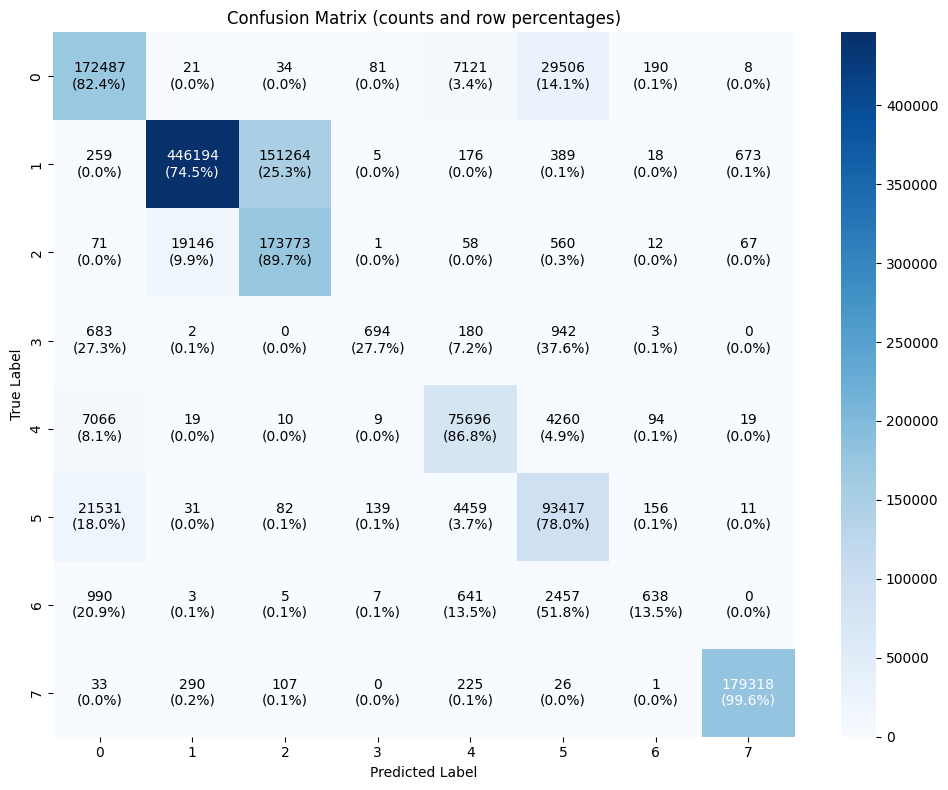

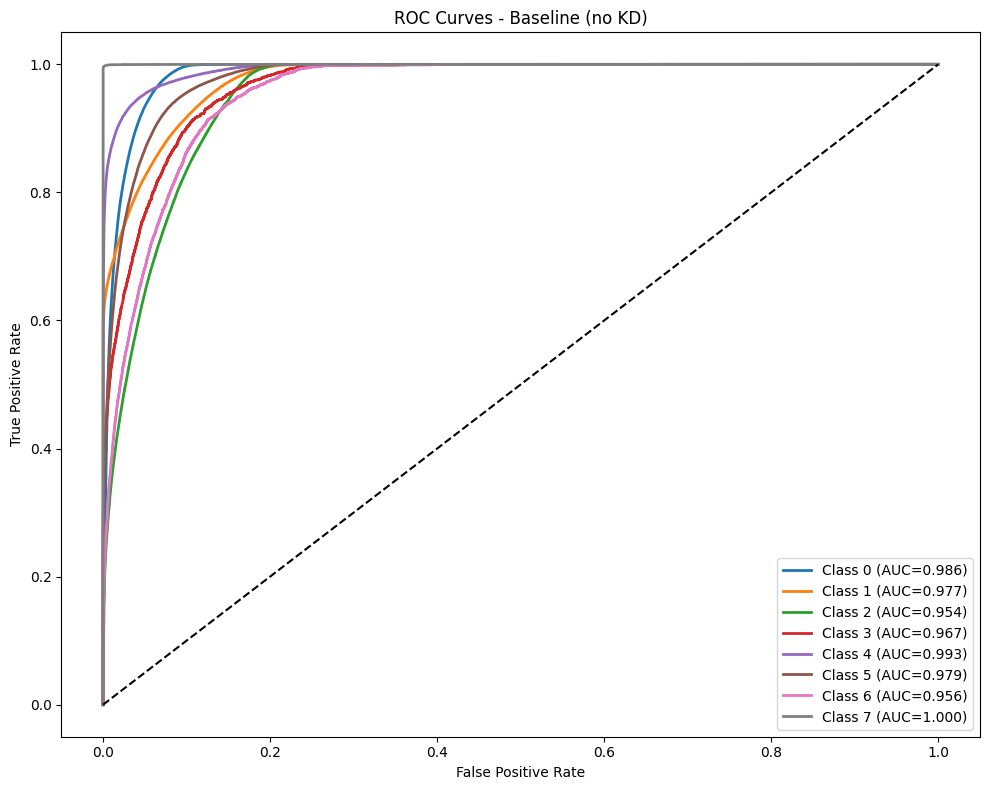

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL: Evaluation (có thể chạy độc lập hoặc sau khi train)
# ──────────────────────────────────────────────────────────────────────────────

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Cấu hình -----
# Đường dẫn đến model đã train (dùng khi chạy độc lập)
MODEL_PATH = "/kaggle/working/mlp_baseline_best.keras"      # File model tốt nhất từ training
METADATA_PATH = "/kaggle/working/metadata.json"
TEST_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
BATCH_SIZE = 128
OUTPUT_DIR = "/kaggle/working/"   # Thư mục output để lưu ảnh

# ----- 1. Load metadata -----
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)
num_classes = metadata['num_classes']
feature_cols = metadata['feature_cols']
target_col = metadata['target_col']

# ----- 2. Load model (nếu chưa có sẵn) -----
try:
    # Nếu biến 'student' đã tồn tại (từ training), dùng nó
    student
except NameError:
    print("Loading model from file...")
    student = tf.keras.models.load_model(MODEL_PATH)
    print("Model loaded.")

# ----- 3. Load dữ liệu test -----
df_test = pd.read_parquet(TEST_PATH)
X_test = df_test[feature_cols].values.astype(np.float32)
y_test = df_test[target_col].values.astype(np.int32)

# ----- 4. Dự đoán -----
test_logits = student.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_preds = np.argmax(test_logits, axis=1)
test_probs = tf.nn.softmax(test_logits).numpy()

# ----- 5. Classification Report với 4 số thập phân -----
print("\n" + "="*60)
print("CLASSIFICATION REPORT (digits=4)")
print("="*60)
print(classification_report(y_test, test_preds, digits=4, zero_division=0))

# ----- 6. AUC (macro, weighted, micro) -----
y_bin = label_binarize(y_test, classes=range(num_classes))
auc_macro = roc_auc_score(y_bin, test_probs, average='macro', multi_class='ovr')
auc_weighted = roc_auc_score(y_bin, test_probs, average='weighted', multi_class='ovr')
auc_micro = roc_auc_score(y_bin, test_probs, average='micro', multi_class='ovr')
print("\n" + "-"*40)
print(f"Macro AUC   : {auc_macro:.4f}")
print(f"Weighted AUC: {auc_weighted:.4f}")
print(f"Micro AUC   : {auc_micro:.4f}")
print("-"*40)

# ----- 7. Confusion Matrix với count và % theo hàng -----
cm = confusion_matrix(y_test, test_preds)
# Tính phần trăm theo hàng (mỗi hàng = nhãn thực tế)
cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)

# Thêm annotation thủ công (count + percentage)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = cm_percent[i, j]
        # Chọn màu chữ tương phản
        color = 'white' if count > cm.max() * 0.4 else 'black'
        plt.text(j + 0.5, i + 0.5, f"{count}\n({pct:.1f}%)",
                 ha='center', va='center', color=color, fontsize=10)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (counts and row percentages)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_with_pct_baseline.png", dpi=150)
plt.show()

# ----- 8. ROC curves (tùy chọn) -----
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={roc_auc_score(y_bin[:, i], test_probs[:, i]):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Baseline (no KD)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves_baseline.png", dpi=150)
plt.show()